In [1]:
# 0) Imports & paths
from pathlib import Path
import pandas as pd
import numpy as np
import re

# Project-relative paths (notebook lives in /notebooks, so go up one level)
PROJ = Path("..").resolve()
RAW   = PROJ / "data" / "raw"
PROC  = PROJ / "data" / "processed"
PROC.mkdir(parents=True, exist_ok=True)

print("PROC:", PROC)

PROC: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed


In [4]:
# 1) Helpers

def smart_rename(df, mapping):
    """Rename only columns that exist; ignore missing keys."""
    present = {k:v for k,v in mapping.items() if k in df.columns}
    return df.rename(columns=present)

def require_cols(df, need, name="df"):
    """Assert the dataframe has the columns we need."""
    missing = [c for c in need if c not in df.columns]
    assert not missing, f"{name} missing cols: {missing}"
    return df

def best_first_match(cols, candidates, default=None, flags=re.I):
    """Return the first column in `cols` that matches any regex in `candidates`."""
    for pat in candidates:
        reg = re.compile(pat, flags)
        for c in cols:
            if reg.search(c):
                return c
    return default

In [6]:
# --- ILO Unemployment: add iso3 from World Bank + clean & save ---

import pandas as pd
from pathlib import Path

PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"

# Inputs / outputs
ILO_U_PATH = PROC / "unemployment_clean.csv"            # your raw-ish ILO unemployment (already in processed/)
WB_PATH    = PROC / "worldbank_econ_clean.csv"          # from 02_worldbank_clean.ipynb
OUT_UNEMP  = PROC / "ilo_unemployment_clean.csv"        # standardized output we will create

# 1) Load
u = pd.read_csv(ILO_U_PATH)
wb = pd.read_csv(WB_PATH, usecols=["iso3","country"])   # use only country mapping
wb_map = wb.drop_duplicates().copy()

print("ILO cols:", u.columns.tolist())
display(u.head())

# 2) Keep only total (not by sex/age), if you want the overall series
#    If you need sex/age later, skip these two filters.
if "sex" in u.columns:
    u = u[u["sex"].str.upper().eq("TOTAL") | u["sex"].isna()].copy()
if "age_group" in u.columns:
    # keep '15+' or total if available; tweak if your file uses a different label
    u = u[u["age_group"].isin(["15+","Total","TOTAL"]) | u["age_group"].isna()].copy()

# 3) Merge in iso3 using country name (left join keeps all ILO rows)
u2 = u.merge(wb_map, on="country", how="left")

# Report unmatched country names (so you can fix them once)
missing_iso = u2[u2["iso3"].isna()]["country"].drop_duplicates().sort_values()
print(f"Countries without iso3 after merge: {len(missing_iso)}")
display(missing_iso.head(30))

# (Optional) quick manual fixes for common mismatches
fix = {
    "Côte d'Ivoire": "CIV",
    "Congo, Dem. Rep.": "COD",
    "Congo, Rep.": "COG",
    "Eswatini": "SWZ",
    "Kyrgyzstan": "KGZ",
    "Lao People's Democratic Republic": "LAO",
    "North Macedonia": "MKD",
    "Russian Federation": "RUS",
    "Türkiye": "TUR",
    "Viet Nam": "VNM",
    "Iran (Islamic Republic of)": "IRN",
    "Syrian Arab Republic": "SYR",
    "United States of America": "USA",
    "United Kingdom": "GBR",
}
u2.loc[u2["country"].isin(fix.keys()), "iso3"] = u2["country"].map(fix)

# 4) Standardize columns
u2 = u2.rename(columns={"unemployment_rate": "unemp_total_pct"})
keep_cols = ["iso3","country","year","unemp_total_pct"]
u2 = u2[keep_cols].copy()

# 5) Types & simple sanity
u2["year"] = pd.to_numeric(u2["year"], errors="coerce").astype("Int64")
u2["unemp_total_pct"] = pd.to_numeric(u2["unemp_total_pct"], errors="coerce")

print("Year span:", u2["year"].min(), "→", u2["year"].max())
print("Rows:", len(u2), "Missing iso3:", u2["iso3"].isna().sum(), "Missing rate:", u2["unemp_total_pct"].isna().sum())

# 6) Range check for a % series (allowing tiny float noise)
bad = u2[(u2["unemp_total_pct"] < -0.1) | (u2["unemp_total_pct"] > 100.1)]
print("Out-of-range rows:", len(bad))
if len(bad):
    display(bad.head())

# 7) Save
u2.to_csv(OUT_UNEMP, index=False)
print("✅ Saved", OUT_UNEMP, "shape:", u2.shape)

ILO cols: ['country', 'year', 'sex', 'age_group', 'labour_force_thousands', 'unemployed_thousands', 'unemployment_rate', 'source_lf', 'source_unemp']


,country,year,sex,age_group,labour_force_thousands,unemployed_thousands,unemployment_rate,source_lf,source_unemp
0,Afghanistan,2008,Female,15+,2608.202,57.045,2.187139,HIES - Households Living Conditions Survey,HIES - Households Living Conditions Survey
1,Afghanistan,2008,Female,15-19,326.231,16.122,4.941897,HIES - Households Living Conditions Survey,HIES - Households Living Conditions Survey
2,Afghanistan,2008,Female,15-24,696.889,27.538,3.951562,HIES - Households Living Conditions Survey,HIES - Households Living Conditions Survey
3,Afghanistan,2008,Female,15-64,2565.047,54.605,2.128811,HIES - Households Living Conditions Survey,HIES - Households Living Conditions Survey
4,Afghanistan,2008,Female,20-24,370.658,11.416,3.079928,HIES - Households Living Conditions Survey,HIES - Households Living Conditions Survey


Countries without iso3 after merge: 44


137                              Anguilla
498                               Bahamas
881      Bolivia (Plurinational State of)
1617                                Congo
1621    Congo, Democratic Republic of the
1627                         Cook Islands
1760                              Curaçao
1909                        Côte d'Ivoire
2142                                Egypt
2370           Falkland Islands, Malvinas
2606                        French Guiana
2630                               Gambia
2783                            Gibraltar
2924                           Guadeloupe
3005                             Guernsey
3099                     Hong Kong, China
3428           Iran (Islamic Republic of)
3982                               Jersey
4116                           Kyrgyzstan
4159     Lao People's Democratic Republic
4422                         Macao, China
4681                           Martinique
4843     Micronesia (Federated States of)
4929                           Mon

Year span: 1947 → 2025
Rows: 8535 Missing iso3: 1194 Missing rate: 0
Out-of-range rows: 0
✅ Saved /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/ilo_unemployment_clean.csv shape: (8535, 4)


In [8]:
# Extend manual fixes for ILO country names
fix.update({
    "Bolivia (Plurinational State of)": "BOL",
    "Congo": "COG",   # Congo, Rep.
    "Congo, Democratic Republic of the": "COD",
    "Cook Islands": "COK",
    "Curaçao": "CUW",
    "Côte d'Ivoire": "CIV",
    "Egypt": "EGY",
    "Falkland Islands (Malvinas)": "FLK",
    "French Guiana": "GUF",
    "Gambia": "GMB",
    "Gibraltar": "GIB",
    "Guadeloupe": "GLP",
    "Guernsey": "GGY",
    "Hong Kong, China": "HKG",
    "Iran (Islamic Republic of)": "IRN",
    "Jersey": "JEY",
    "Kyrgyzstan": "KGZ",
    "Lao People's Democratic Republic": "LAO",
    "Macao, China": "MAC",
    "Martinique": "MTQ",
    "Micronesia (Federated States of)": "FSM",
    "Montserrat": "MSR",
    "Netherlands Antilles": "ANT",  # dissolved in 2010, use ANT for historic
    "Occupied Palestinian Territory": "PSE",
    "Puerto Rico": "PRI",
    "Republic of Korea": "KOR",
    "Republic of Moldova": "MDA",
    "Syrian Arab Republic": "SYR",
    "United States of America": "USA",
    "United Kingdom": "GBR",
    "Viet Nam": "VNM",
    "Türkiye": "TUR",
})

# Apply again
u2.loc[u2["country"].isin(fix.keys()), "iso3"] = u2["country"].map(fix)

# Re-check
missing_iso = u2[u2["iso3"].isna()]["country"].drop_duplicates().sort_values()
print(f"Countries still without iso3 after fixes: {len(missing_iso)}")
display(missing_iso.head(30))

Countries still without iso3 after fixes: 16


137                                              Anguilla
498                                               Bahamas
2370                           Falkland Islands, Malvinas
5319                                                 Niue
6525                                              Réunion
6539                                         Saint Helena
6547                                Saint Kitts and Nevis
6553                                          Saint Lucia
6590                     Saint Vincent and the Grenadines
6870                                             Slovakia
7442                                        Taiwan, China
7546                         Tanzania, United Republic of
8003    United Kingdom of Great Britain and Northern I...
8359                   Venezuela (Bolivarian Republic of)
8454                                    Wallis and Futuna
8460                                                Yemen
Name: country, dtype: object

In [9]:
# Keep only the analysis window
u2 = u2[(u2["year"] >= 2000) & (u2["year"] <= 2023)].copy()
print("After year filter:", u2["year"].min(), "→", u2["year"].max(), "| rows:", len(u2))

# Save
OUT_UNEMP = PROC / "ilo_unemployment_clean.csv"
u2[["iso3","country","year","unemp_total_pct"]].to_csv(OUT_UNEMP, index=False)
print("✅ Saved unemployment to:", OUT_UNEMP)

After year filter: 2000 → 2023 | rows: 5568
✅ Saved unemployment to: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/ilo_unemployment_clean.csv


In [13]:
from pathlib import Path
import pandas as pd

# --- Paths
PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"

SRC_TOTALS = PROC / "totals_country_year.csv"           # your totals source
SRC_WB      = PROC / "worldbank_econ_clean.csv"         # already created earlier
OUT_TOTALS  = PROC / "ilo_totals_clean.csv"

# --- Load
totals = pd.read_csv(SRC_TOTALS)
print("Loaded totals:", SRC_TOTALS)
print("Totals columns:", list(totals.columns))

# --- Rename to project schema
rename_map = {
    "country": "country",
    "year": "year",
    "value_lf": "labor_force_thousands",
    "value_unemp": "unemployed_thousands",
    # 'unemployment_rate' we keep as-is for reference; not required for merge
}
totals = totals.rename(columns=rename_map)

# --- Add ISO3 by merging with WB country map
wb_map = (
    pd.read_csv(SRC_WB, usecols=["iso3","country"])
      .drop_duplicates()
)

totals = totals.merge(wb_map, on="country", how="left")

# A few stubborn names may still be missing iso3 — quick manual fixes (extend if needed)
fix = {
    "United States": "USA",
    "United Kingdom": "GBR",
    "Korea, Rep.": "KOR",
    "Russian Federation": "RUS",
    "Viet Nam": "VNM",
    "Iran (Islamic Republic of)": "IRN",
    "Egypt": "EGY",
    # add more if you see warnings printed below
}
totals.loc[totals["country"].isin(fix.keys()), "iso3"] = totals["country"].map(fix)

missing_iso = totals[totals["iso3"].isna()]["country"].drop_duplicates()
if not missing_iso.empty:
    print("Countries still without iso3 (fix later if they matter):")
    display(missing_iso.head(30))

# --- Types
totals["year"] = totals["year"].astype(int)
for c in ["labor_force_thousands", "unemployed_thousands"]:
    if c in totals.columns:
        totals[c] = pd.to_numeric(totals[c], errors="coerce")

# --- Filter years 2000–2023
totals = totals[(totals["year"] >= 2000) & (totals["year"] <= 2023)].copy()
print("Year span:", totals["year"].min(), "→", totals["year"].max(), "| rows:", len(totals))

# --- Final column order & save
need = ["iso3", "country", "year", "labor_force_thousands", "unemployed_thousands"]
# keep unemployment_rate if present
if "unemployment_rate" in totals.columns:
    need = need + ["unemployment_rate"]

missing = [c for c in need if c not in totals.columns]
assert not missing, f"Still missing columns: {missing}"

totals[need].to_csv(OUT_TOTALS, index=False)
print("✅ Saved totals to:", OUT_TOTALS)

Loaded totals: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/totals_country_year.csv
Totals columns: ['country', 'year', 'unemployment_rate', 'value_lf', 'value_unemp']
Countries still without iso3 (fix later if they matter):


132                              Anguilla
619                               Bahamas
1048     Bolivia (Plurinational State of)
1925                                Congo
1931    Congo, Democratic Republic of the
1940                         Cook Islands
2102                              Curaçao
2312                        Côte d'Ivoire
2909           Falkland Islands, Malvinas
3194                        French Guiana
3209                               Gambia
3669                             Guernsey
3783                     Hong Kong, China
5058                           Kyrgyzstan
5115     Lao People's Democratic Republic
5455                         Macao, China
5754                           Martinique
5956     Micronesia (Federated States of)
6070                           Montserrat
6298                 Netherlands Antilles
6531                                 Niue
6738       Occupied Palestinian Territory
7487                          Puerto Rico
7595                    Republic o

Year span: 2000 → 2023 | rows: 7551
✅ Saved totals to: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/ilo_totals_clean.csv


In [15]:
from pathlib import Path
import pandas as pd
import re

PROJ = Path("..").resolve()
RAW  = PROJ / "data" / "raw"
PROC = PROJ / "data" / "processed"
OUT_AGE = PROC / "ilo_age10_clean.csv"
SRC_WB  = PROC / "worldbank_econ_clean.csv"

# 1) Find the ILO age-by-sex files you downloaded
candidates = list(RAW.glob("*AGE*NB*A*.csv"))
print("Found AGE files:", [c.name for c in candidates])
assert candidates, "Couldn't find AGE files in data/raw. Check filenames."

def normalize_cols(df: pd.DataFrame) -> pd.DataFrame:
    """Lowercase, strip, collapse spaces/punct to underscores."""
    def norm(s):
        s = s.strip().lower()
        s = re.sub(r"[^\w\s]", " ", s)     # drop non-word punct
        s = re.sub(r"\s+", "_", s)         # spaces -> _
        return s
    df = df.copy()
    df.columns = [norm(c) for c in df.columns]
    return df

def pick_col(df, options, contains_any=None):
    """Pick the first column whose name is in options OR contains any of the substrings."""
    cols = list(df.columns)
    if options:
        for o in options:
            if o in df.columns:
                return o
    if contains_any:
        for c in cols:
            if any(sub in c for sub in contains_any):
                return c
    return None

dfs = []
for p in candidates:
    d = pd.read_csv(p)
    print(f"\n>> {p.name} columns:", list(d.columns)[:12], "...")
    d = normalize_cols(d)
    dfs.append(d)

age = pd.concat(dfs, ignore_index=True)

# 2) Work out canonical column names
country_col = pick_col(age, options=["country"], contains_any=["country"])
year_col    = pick_col(age, options=["year","reference_year"], contains_any=["year"])
sex_col     = pick_col(age, options=["sex"], contains_any=["sex"])
agegrp_col  = pick_col(age, options=["age_group","age"], contains_any=["age_group","age"])

lf_col   = pick_col(age,
                    options=["labour_force_thousands","labor_force_thousands","labour_force","labor_force"],
                    contains_any=["labour_force","labor_force"])
unemp_n_col = pick_col(age,
                      options=["unemployed_thousands","unemployed"],
                      contains_any=["unemploy","thousand"])
unemp_r_col = pick_col(age,
                      options=["unemployment_rate","unemployment_rate_%","unemployment_rate_pct"],
                      contains_any=["unemployment_rate"])

print("\nDetected columns:")
print(" country   ->", country_col)
print(" year      ->", year_col)
print(" sex       ->", sex_col)
print(" age_group ->", agegrp_col)
print(" labour_force_thousands    ->", lf_col)
print(" unemployed_thousands      ->", unemp_n_col)
print(" unemployment_rate         ->", unemp_r_col)

need_any = [country_col, year_col]
assert all(need_any), "Missing critical columns (country/year). Please show me age.columns() so I can adjust."

# 3) Build a tidy frame with unified names
keep_map = {}
keep_map[country_col] = "country"
keep_map[year_col]    = "year"
if sex_col:        keep_map[sex_col]       = "sex"
if agegrp_col:     keep_map[agegrp_col]    = "age_group"
if lf_col:         keep_map[lf_col]        = "labor_force_thousands"
if unemp_n_col:    keep_map[unemp_n_col]   = "unemployed_thousands"
if unemp_r_col:    keep_map[unemp_r_col]   = "unemployment_rate"

age = age[list(keep_map.keys())].rename(columns=keep_map).copy()

# 4) Types
age["year"] = pd.to_numeric(age["year"], errors="coerce").astype("Int64")
for c in ["labor_force_thousands","unemployed_thousands","unemployment_rate"]:
    if c in age.columns:
        age[c] = pd.to_numeric(age[c], errors="coerce")

# 5) Add iso3 by merging WB country list
wb_map = pd.read_csv(SRC_WB, usecols=["iso3","country"]).drop_duplicates()
age = age.merge(wb_map, on="country", how="left")

# 6) Filter years + save
age = age[(age["year"] >= 2000) & (age["year"] <= 2023)].copy()
print("\nAGE10 rows:", len(age), "| span:", age["year"].min(), "→", age["year"].max())
display(age.head(10))

PROC.mkdir(parents=True, exist_ok=True)
age.to_csv(OUT_AGE, index=False)
print("✅ Saved AGE10 to:", OUT_AGE)

Found AGE files: ['EAP_TEAP_SEX_AGE_NB_A-20250819T1611.csv', 'UNE_TUNE_SEX_AGE_NB_A-20250819T1613.csv']

>> EAP_TEAP_SEX_AGE_NB_A-20250819T1611.csv columns: ['ref_area.label', 'source.label', 'indicator.label', 'sex.label', 'classif1.label', 'time', 'obs_value', 'obs_status.label', 'note_classif.label', 'note_indicator.label', 'note_source.label'] ...

>> UNE_TUNE_SEX_AGE_NB_A-20250819T1613.csv columns: ['ref_area.label', 'source.label', 'indicator.label', 'sex.label', 'classif1.label', 'time', 'obs_value', 'obs_status.label', 'note_classif.label', 'note_indicator.label', 'note_source.label'] ...

Detected columns:
 country   -> None
 year      -> None
 sex       -> sex_label
 age_group -> None
 labour_force_thousands    -> None
 unemployed_thousands      -> None
 unemployment_rate         -> None


AssertionError: Missing critical columns (country/year). Please show me age.columns() so I can adjust.

In [16]:
from pathlib import Path
import pandas as pd
import re

# --- paths ---
PROJ = Path("..").resolve()
RAW  = PROJ / "data" / "raw"
PROC = PROJ / "data" / "processed"
SRC_WB = PROC / "worldbank_econ_clean.csv"
OUT_AGE = PROC / "ilo_age10_clean.csv"

# --- helpers ---
def norm_cols(df):
    def n(s):
        s = str(s).strip().lower()
        s = re.sub(r"[^\w\s]", " ", s)
        s = re.sub(r"\s+", "_", s)
        return s
    out = df.copy()
    out.columns = [n(c) for c in out.columns]
    return out

def first_col(df, candidates):
    for c in candidates:
        if c in df.columns: 
            return c
    return None

# --- load & combine any AGE-by-sex files in raw ---
files = list(RAW.glob("*AGE*NB*A*.csv"))
print("Found AGE files:", [f.name for f in files])
assert files, "No AGE files found in data/raw. Check filenames."

parts = [norm_cols(pd.read_csv(f)) for f in files]
age = pd.concat(parts, ignore_index=True)

print("\nExample columns:", list(age.columns)[:15])

# --- map SDMX columns to standard names ---
country_col   = first_col(age, ["country","ref_area_label"])
year_col      = first_col(age, ["year","time"])
sex_col       = first_col(age, ["sex_label","sex"])
agegrp_col    = first_col(age, ["classif1_label","age_group","classif1"])
indicator_col = first_col(age, ["indicator_label","indicator","series","series_name"])
value_col     = first_col(age, ["obs_value","value"])

print("\nDetected:")
print(" country   ->", country_col)
print(" year      ->", year_col)
print(" sex       ->", sex_col)
print(" age_group ->", agegrp_col)
print(" indicator ->", indicator_col)
print(" value     ->", value_col)

assert country_col and year_col and indicator_col and value_col, \
    "Missing critical columns. Please show me list(age.columns)."

# --- keep & rename ---
keep = {
    country_col: "country",
    year_col: "year",
    value_col: "value",
    indicator_col: "indicator",
}
if sex_col:    keep[sex_col]    = "sex"
if agegrp_col: keep[agegrp_col] = "age_group"

age = age[list(keep.keys())].rename(columns=keep).copy()

# types
age["year"] = pd.to_numeric(age["year"], errors="coerce").astype("Int64")
age["value"] = pd.to_numeric(age["value"], errors="coerce")

# --- understand what indicators we have ---
inds = (age["indicator"].dropna().unique().tolist())
print("\nUnique indicators (sample up to 12):", inds[:12])

# map indicator text to tidy column names
def which_col(ind_text: str):
    s = ind_text.lower()
    if "unemployment rate" in s:
        return "unemployment_rate"
    if "unemploy" in s and "thousand" in s:
        return "unemployed_thousands"
    if ("labour force" in s or "labor force" in s) and "thousand" in s:
        return "labor_force_thousands"
    return None

age["value_col"] = age["indicator"].astype(str).map(which_col)

# keep only indicators we know how to map
age = age[age["value_col"].notna()].copy()
print("Rows after indicator mapping:", len(age))

# --- pivot long -> wide per (country,year,sex,age_group) ---
index_cols = ["country","year"]
if "sex" in age.columns: index_cols.append("sex")
if "age_group" in age.columns: index_cols.append("age_group")

wide = (
    age.pivot_table(index=index_cols, columns="value_col", values="value", aggfunc="first")
       .reset_index()
)

# --- add iso3 from WB ---
wb_countries = pd.read_csv(SRC_WB, usecols=["iso3","country"]).drop_duplicates()
wide = wide.merge(wb_countries, on="country", how="left")

# filter to analysis window
wide = wide[(wide["year"] >= 2000) & (wide["year"] <= 2023)].copy()

print("\nShape after pivot & filter:", wide.shape)
print("Year span:", wide["year"].min(), "→", wide["year"].max())
missing_iso = wide[wide["iso3"].isna()]["country"].drop_duplicates().sort_values()
print("Countries missing iso3 (first 20):")
display(missing_iso.head(20))

# save
PROC.mkdir(parents=True, exist_ok=True)
wide.to_csv(OUT_AGE, index=False)
print("✅ Saved:", OUT_AGE)
display(wide.head())

Found AGE files: ['EAP_TEAP_SEX_AGE_NB_A-20250819T1611.csv', 'UNE_TUNE_SEX_AGE_NB_A-20250819T1613.csv']

Example columns: ['ref_area_label', 'source_label', 'indicator_label', 'sex_label', 'classif1_label', 'time', 'obs_value', 'obs_status_label', 'note_classif_label', 'note_indicator_label', 'note_source_label']

Detected:
 country   -> ref_area_label
 year      -> time
 sex       -> sex_label
 age_group -> classif1_label
 indicator -> indicator_label
 value     -> obs_value

Unique indicators (sample up to 12): ['Labour force by sex and age (thousands)', 'Unemployment by sex and age (thousands)']
Rows after indicator mapping: 671087

Shape after pivot & filter: (229744, 7)
Year span: 2000 → 2023
Countries missing iso3 (first 20):


4859                               Anguilla
22869                               Bahamas
41567      Bolivia (Plurinational State of)
73751                                 Congo
73977     Congo, Democratic Republic of the
74706                          Cook Islands
80426                               Curaçao
87596                         Côte d'Ivoire
100786                                Egypt
109799           Falkland Islands, Malvinas
120984                        French Guiana
122135                               Gambia
129312                            Gibraltar
135285                           Guadeloupe
138796                             Guernsey
145838                     Hong Kong, China
159773           Iran (Islamic Republic of)
182307                               Jersey
188508                           Kyrgyzstan
190280     Lao People's Democratic Republic
Name: country, dtype: object

✅ Saved: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/ilo_age10_clean.csv


,country,year,sex,age_group,labor_force_thousands,unemployed_thousands,iso3
85,Afghanistan,2008,Female,Age (10-year bands): 15-24,696.889,27.538,AFG
86,Afghanistan,2008,Female,Age (10-year bands): 25-34,784.403,12.669,AFG
87,Afghanistan,2008,Female,Age (10-year bands): 35-44,595.181,7.580,AFG
88,Afghanistan,2008,Female,Age (10-year bands): 45-54,356.608,4.375,AFG
89,Afghanistan,2008,Female,Age (10-year bands): 55-64,131.966,2.443,AFG


In [17]:
import pandas as pd
from pathlib import Path

PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"

# Inputs (already created earlier)
WB   = PROC / "worldbank_econ_clean.csv"          # iso3, country, year, gdp_per_capita_usd, gdp_per_worker_ppp_const, lfpr_total_pct, emp_*_pct, unemp_total_pct? (from WB)
TOT  = PROC / "ilo_totals_clean.csv"              # iso3, country, year, labor_force_thousands, unemployed_thousands
UN   = PROC / "ilo_unemployment_clean.csv"        # iso3, country, year, unemp_total_pct  (ILO modeled)
AGE  = PROC / "ilo_age10_clean.csv"               # iso3, country, year, sex, age_group, labor_force_thousands, unemployed_thousands

wb   = pd.read_csv(WB)
tot  = pd.read_csv(TOT)
un   = pd.read_csv(UN)

# --- Merge a wide country–year master ---
master = (
    wb.merge(tot[["iso3","year","labor_force_thousands","unemployed_thousands"]],
             on=["iso3","year"], how="left")
      .merge(un[["iso3","year","unemp_total_pct"]],
             on=["iso3","year"], how="left", suffixes=("","_ilo"))
)

# Prefer the ILO unemployment percentage when present
if "unemp_total_pct_ilo" in master.columns:
    master["unemp_total_pct"] = master["unemp_total_pct_ilo"].fillna(master.get("unemp_total_pct"))
    master = master.drop(columns=[c for c in ["unemp_total_pct_ilo"] if c in master.columns])

# Housekeeping & checks
master["year"] = master["year"].astype("Int64")
assert master.duplicated(["iso3","year"]).sum() == 0, "Duplicate iso3-year rows found"

# Save
OUT_MASTER = PROC / "master_country_year.csv"
master.to_csv(OUT_MASTER, index=False)
print("✅ Saved:", OUT_MASTER, "| shape:", master.shape)

AssertionError: Duplicate iso3-year rows found

In [18]:
from pathlib import Path
import pandas as pd

PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"

WB  = PROC / "worldbank_econ_clean.csv"       # iso3, country, year, gdp_per_capita_usd, ... (wide)
TOT = PROC / "ilo_totals_clean.csv"           # iso3, country, year, labour_force_thousands, unemployed_thousands
UN  = PROC / "ilo_unemployment_clean.csv"     # iso3, country, year, unemp_total_pct

wb  = pd.read_csv(WB)
tot = pd.read_csv(TOT)
un  = pd.read_csv(UN)

for name, df in [("wb", wb), ("totals", tot), ("unemp", un)]:
    print(name, df.shape, df.columns.tolist()[:10], "…")

wb (4179, 11) ['iso3', 'country', 'year', 'gdp_per_capita_usd', 'school_enroll_tertiary_pct', 'emp_agriculture_pct', 'gdp_per_worker_ppp_const', 'emp_industry_pct', 'emp_services_pct', 'lfpr_total_pct'] …
totals (7551, 6) ['iso3', 'country', 'year', 'labor_force_thousands', 'unemployed_thousands', 'unemployment_rate'] …
unemp (5568, 4) ['iso3', 'country', 'year', 'unemp_total_pct'] …


In [19]:
def dupe_report(df, key=("iso3","year")):
    g = df.groupby(list(key)).size()
    d = g[g>1].sort_values(ascending=False)
    return d

print("WB dupes:\n", dupe_report(wb).head(10))
print("\nTOT dupes:\n", dupe_report(tot).head(10))
print("\nUN dupes:\n", dupe_report(un).head(10))

WB dupes:
 Series([], dtype: int64)

TOT dupes:
 iso3  year
ABW   2007    3
MYS   2020    3
NCL   2020    3
      2019    3
      2018    3
      2017    3
      2014    3
NAM   2018    3
      2016    3
      2014    3
dtype: int64

UN dupes:
 iso3  year
ABW   2007    2
NCL   2014    2
NAM   2004    2
      2010    2
      2012    2
      2013    2
      2014    2
      2016    2
      2018    2
NCL   2017    2
dtype: int64


In [20]:
# Identify numeric columns
wb_num  = [c for c in wb.columns if c not in ("iso3","country","year")]
tot_num = [c for c in tot.columns if c not in ("iso3","country","year")]
un_num  = [c for c in un.columns  if c not in ("iso3","country","year")]

# Collapse duplicates if any
wb_u  = wb.groupby(["iso3","year","country"], as_index=False)[wb_num].mean(numeric_only=True)

# For totals: sum 'thousands', mean any rates (if present)
tot_agg = {}
for c in tot_num:
    tot_agg[c] = "sum" if c.endswith("_thousands") else "mean"
tot_u = tot.groupby(["iso3","year","country"], as_index=False).agg(tot_agg)

# For unemployment (%): mean to collapse (should be identical anyway)
un_u = un.groupby(["iso3","year","country"], as_index=False)[un_num].mean(numeric_only=True)

# Sanity: prove uniqueness now
for name, df in [("wb_u", wb_u), ("tot_u", tot_u), ("un_u", un_u)]:
    assert dupe_report(df).empty, f"{name} still has duplicates"
print("All inputs are unique at (iso3, year).")

All inputs are unique at (iso3, year).


In [23]:
# Check each input again (right before the merge)
print("WB dupes:",  wb_u.duplicated(["iso3","year"]).sum())
print("TOT dupes:", tot_u.duplicated(["iso3","year"]).sum())
print("UN dupes:",  un_u.duplicated(["iso3","year"]).sum())

# Which (iso3,year) are duplicated in the merged frame?
dupes = master[master.duplicated(["iso3","year"], keep=False)]
print("Master duped rows:", len(dupes))
display(
    dupes[["iso3","country","year"]]
      .value_counts()
      .reset_index(name="n")
      .sort_values(["iso3","year","n"], ascending=[True,True,False])
      .head(20)
)

WB dupes: 0
TOT dupes: 5334
UN dupes: 2704
Master duped rows: 8564


,iso3,country,year,n
0,ABW,Aruba,2007,6
183,AFG,Afghanistan,2017,6
1137,AFG,Afghanistan,2020,6
1138,AFG,Afghanistan,2021,6
1139,AGO,Angola,2004,6
1140,AGO,Angola,2019,6
1141,AGO,Angola,2021,6
1142,AGO,Angola,2022,6
1116,ALB,Albania,2002,6
1435,ALB,Albania,2003,2


In [24]:
# 1) Load the three inputs (use the same paths you used earlier)
from pathlib import Path
import pandas as pd

PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"

WB  = PROC / "worldbank_econ_clean.csv"      # wide: iso3, country, year, ...
TOT = PROC / "ilo_totals_clean.csv"          # iso3, country, year, labour_force_thousands, unemployed_thousands, unemployment_rate?
UN  = PROC / "ilo_unemployment_clean.csv"    # iso3, country, year, unemp_total_pct

wb  = pd.read_csv(WB)
tot = pd.read_csv(TOT)
un  = pd.read_csv(UN)

# 2) Helper to collapse: sum *_thousands, mean everything else; keep 1 country label
def collapse_by_year(df):
    df = df.copy()
    num_cols  = [c for c in df.columns if c not in ["iso3","country","year"]]
    sum_cols  = [c for c in num_cols if c.endswith("_thousands")]
    mean_cols = [c for c in num_cols if c not in sum_cols]
    agg = {"country":"first"}
    agg.update({c:"sum"  for c in sum_cols})
    agg.update({c:"mean" for c in mean_cols})
    return df.groupby(["iso3","year"], as_index=False).agg(agg)

# 3) Collapse each input (wb is usually unique already, but we’ll be safe)
wb_u  = collapse_by_year(wb)
tot_u = collapse_by_year(tot)
un_u  = collapse_by_year(un)

print("wb_u dupes:",  wb_u.duplicated(["iso3","year"]).sum())
print("tot_u dupes:", tot_u.duplicated(["iso3","year"]).sum())
print("un_u dupes:",  un_u.duplicated(["iso3","year"]).sum())

wb_u dupes: 0
tot_u dupes: 0
un_u dupes: 0


In [26]:
# 0) Quick peek (optional, just to see what's available)
print("tot_u cols:", tot_u.columns.tolist())
print("un_u cols :", un_u.columns.tolist())

# 1) Choose only the totals columns that actually exist in your file
tot_cols_wanted = ["labor_force_thousands", "unemployed_thousands", "unemployment_rate"]  # US spelling
tot_cols = [c for c in tot_cols_wanted if c in tot_u.columns]

# 2) Build master with safe selections
master = (
    wb_u
      .merge(
          tot_u[["iso3", "year"] + tot_cols],
          on=["iso3", "year"], how="left"
      )
      .merge(
          un_u[["iso3", "year", "unemp_total_pct"]],
          on=["iso3", "year"], how="left", suffixes=("", "_ilo")
      )
)

# 3) Prefer ILO unemployment percent when available
if "unemp_total_pct_ilo" in master.columns:
    master["unemp_total_pct"] = master["unemp_total_pct_ilo"].fillna(master["unemp_total_pct"])
    master = master.drop(columns=[c for c in ["unemp_total_pct_ilo"] if c in master.columns])

# 4) Housekeeping + final sanity
master["year"] = master["year"].astype("Int64")
assert master.duplicated(["iso3","year"]).sum() == 0, "Duplicate iso3–year rows found"

# 5) Save
from pathlib import Path
PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"
OUT_MASTER = PROC / "master_country_year.csv"
master.to_csv(OUT_MASTER, index=False)
print("✅ Saved:", OUT_MASTER, "| shape:", master.shape)

# (optional) peek
master.head()

tot_u cols: ['iso3', 'year', 'country', 'labor_force_thousands', 'unemployed_thousands', 'unemployment_rate']
un_u cols : ['iso3', 'year', 'country', 'unemp_total_pct']
✅ Saved: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/master_country_year.csv | shape: (4179, 14)


,iso3,year,country,gdp_per_capita_usd,school_enroll_tertiary_pct,emp_agriculture_pct,gdp_per_worker_ppp_const,emp_industry_pct,emp_services_pct,lfpr_total_pct,unemp_total_pct,labor_force_thousands,unemployed_thousands,unemployment_rate
0,ABW,2000,Aruba,20681.023027,27.973761,NaN,NaN,NaN,NaN,NaN,6.923350,NaN,NaN,NaN
1,ABW,2001,Aruba,20740.132583,29.228010,NaN,NaN,NaN,NaN,NaN,6.923965,NaN,NaN,NaN
2,ABW,2002,Aruba,21307.248251,28.924419,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABW,2003,Aruba,21949.485996,29.782690,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABW,2004,Aruba,23700.631990,29.293449,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
import pandas as pd
from pathlib import Path

PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"
MASTER = PROC / "master_country_year.csv"

m = pd.read_csv(MASTER)
print("Shape:", m.shape)
print("Years:", m['year'].min(), "→", m['year'].max())
print("Countries:", m['iso3'].nunique())

# Missingness overview for key columns
key_cols = [
    'gdp_per_capita_usd','gdp_per_worker_ppp_const',
    'lfpr_total_pct','unemp_total_pct',
    'emp_agriculture_pct','emp_industry_pct','emp_services_pct',
    'labor_force_thousands','unemployed_thousands'
]
present = [c for c in key_cols if c in m.columns]
print("Checking:", present)
na = m[present].isna().sum().sort_values(ascending=False)
display(na.to_frame('n_missing').assign(pct=lambda d: (d['n_missing']/len(m)*100).round(1)))

Shape: (4179, 14)
Years: 2000 → 2023
Countries: 264
Checking: ['gdp_per_capita_usd', 'gdp_per_worker_ppp_const', 'lfpr_total_pct', 'unemp_total_pct', 'emp_agriculture_pct', 'emp_industry_pct', 'emp_services_pct', 'labor_force_thousands', 'unemployed_thousands']


,n_missing,pct
labor_force_thousands,2783,66.6
unemployed_thousands,2783,66.6
gdp_per_worker_ppp_const,594,14.2
lfpr_total_pct,423,10.1
emp_agriculture_pct,423,10.1
emp_industry_pct,423,10.1
emp_services_pct,423,10.1
unemp_total_pct,318,7.6
gdp_per_capita_usd,75,1.8


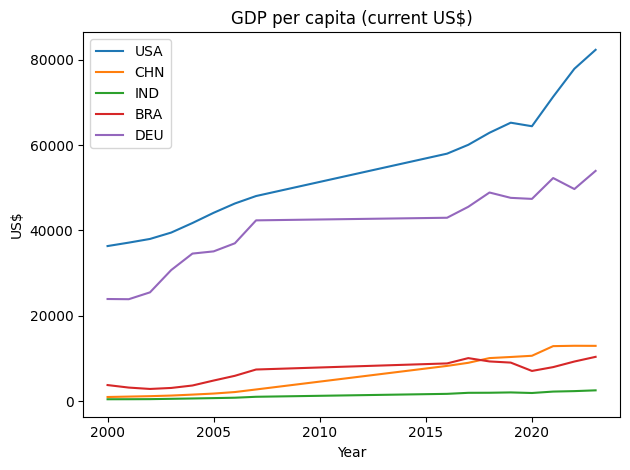

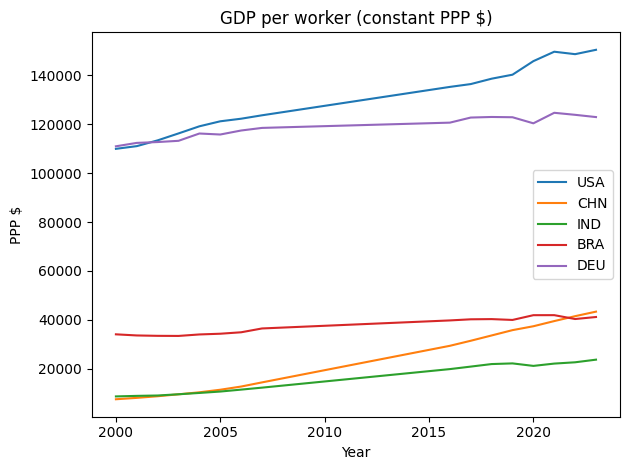

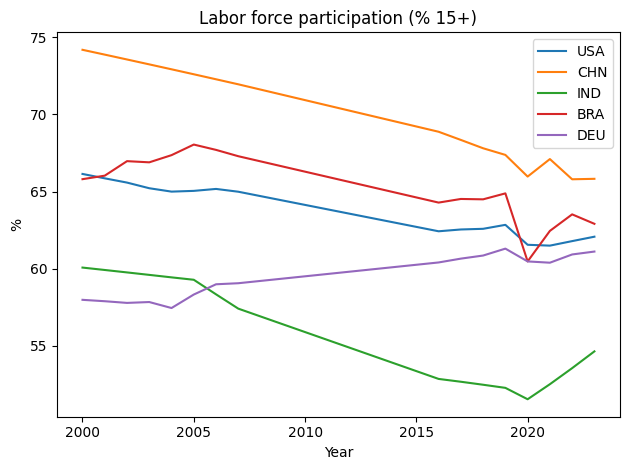

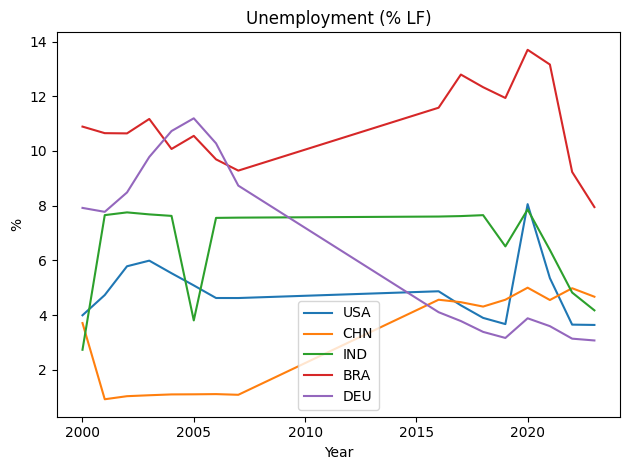

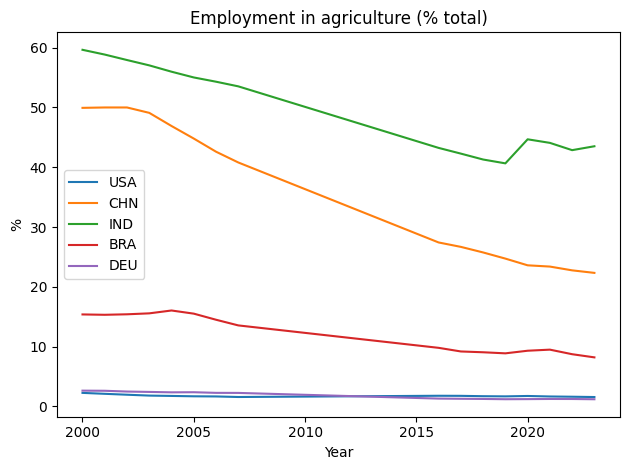

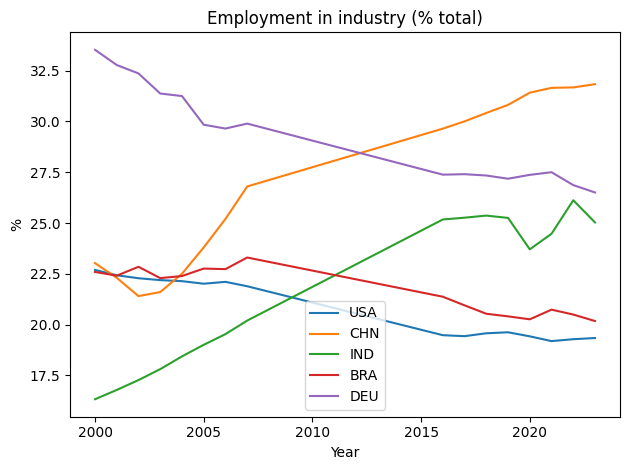

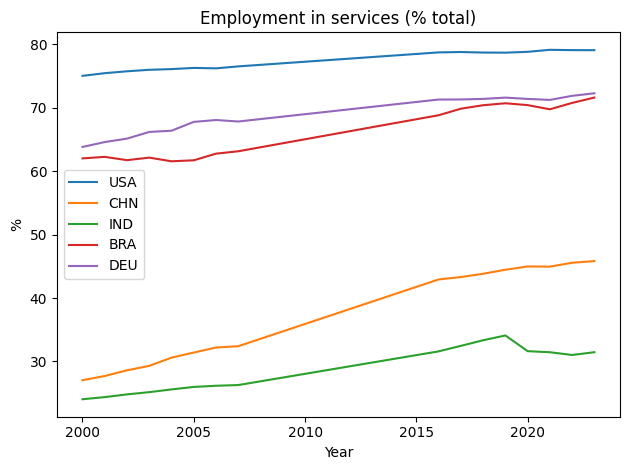

In [28]:
import matplotlib.pyplot as plt

countries = ["USA","CHN","IND","BRA","DEU"]  # change as you like
def lineplot(col, title, ylabel):
    plt.figure()
    for c in countries:
        sub = m[m["iso3"]==c].sort_values("year")
        if col in sub.columns:
            plt.plot(sub["year"], sub[col], label=c)
    plt.title(title); plt.xlabel("Year"); plt.ylabel(ylabel)
    plt.legend(); plt.tight_layout()

lineplot("gdp_per_capita_usd", "GDP per capita (current US$)", "US$")
lineplot("gdp_per_worker_ppp_const", "GDP per worker (constant PPP $)", "PPP $")
lineplot("lfpr_total_pct", "Labor force participation (% 15+)", "%")
lineplot("unemp_total_pct", "Unemployment (% LF)", "%")
for col, ttl in [("emp_agriculture_pct","Employment in agriculture (% total)"),
                 ("emp_industry_pct","Employment in industry (% total)"),
                 ("emp_services_pct","Employment in services (% total)")]:
    lineplot(col, ttl, "%")

In [29]:
# pick the columns you’ll actually use downstream
keep = ["iso3","country","year"] + present
m[keep].to_csv(PROC / "master_country_year_skinny.csv", index=False)
print("Saved skinny →", PROC / "master_country_year_skinny.csv")

Saved skinny → /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/master_country_year_skinny.csv


In [30]:
from pathlib import Path
import pandas as pd

PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"
MASTER = PROC / "master_country_year.csv"

m = pd.read_csv(MASTER)

# 1) No duplicate country-year
assert m.duplicated(['iso3','year']).sum() == 0, "Duplicate iso3-year rows"

# 2) Ranges sanity
assert (m['lfpr_total_pct'].dropna().between(-0.1,100.1)).all()
assert (m['unemp_total_pct'].dropna().between(-0.1,100.1)).all()
for c in ['emp_agriculture_pct','emp_industry_pct','emp_services_pct']:
    if c in m:
        assert (m[c].dropna().between(-0.1,100.1)).all()

print("QA OK → rows:", len(m), "| years:", m['year'].min(), "→", m['year'].max())

QA OK → rows: 4179 | years: 2000 → 2023


In [31]:
from pathlib import Path
import pandas as pd
import numpy as np

PROJ = Path("..").resolve()
PROC = PROJ / "data" / "processed"
SRC  = PROC / "master_country_year.csv"          # the file you saved earlier
OUT  = PROC / "master_country_year_clean.csv"    # new, tidy file

# columns we actually want in Postgres, in order
keep = [
    "iso3","year","country",
    "gdp_per_capita_usd","school_enroll_tertiary_pct",
    "emp_agriculture_pct","gdp_per_worker_ppp_const",
    "emp_industry_pct","emp_services_pct",
    "lfpr_total_pct","unemp_total_pct",
    "labor_force_thousands","unemployed_thousands",
]

df = pd.read_csv(SRC, dtype={"iso3":"string","country":"string"})
# keep only these columns, in this order
df = df[keep].copy()

# tidy types
df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
num_cols = [c for c in keep if c not in ("iso3","country","year")]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# drop rows with no iso3 or year (optional safety)
df = df.dropna(subset=["iso3","year"])

# remove any accidental whitespace that could produce weird commas
df["iso3"] = df["iso3"].str.strip()
df["country"] = df["country"].str.strip()

# sanity: confirm column count == 13
assert list(df.columns) == keep

# write a squeaky-clean CSV: NO index, NO extra columns
df.to_csv(OUT, index=False)
print("Wrote:", OUT, "| rows:", len(df), "| cols:", len(df.columns))

Wrote: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/master_country_year_clean.csv | rows: 4179 | cols: 13


In [32]:
import re

# function to convert any string to snake_case
def to_snake_case(name):
    name = name.strip()  # remove leading/trailing spaces
    name = re.sub(r'[^\w\s]', '', name)  # remove weird symbols
    name = re.sub(r'\s+', '_', name)  # spaces -> underscores
    return name.lower()

# apply to all columns
df.columns = [to_snake_case(col) for col in df.columns]

print("Standardized column names:", df.columns.tolist())

Standardized column names: ['iso3', 'year', 'country', 'gdp_per_capita_usd', 'school_enroll_tertiary_pct', 'emp_agriculture_pct', 'gdp_per_worker_ppp_const', 'emp_industry_pct', 'emp_services_pct', 'lfpr_total_pct', 'unemp_total_pct', 'labor_force_thousands', 'unemployed_thousands']


In [33]:
# Tag rows that are regions (like 'Arab World', 'West Africa', etc.)
regions_list = [
    "Arab World", "West Africa", "East Asia & Pacific", "Europe & Central Asia",
    "Latin America & Caribbean", "Middle East & North Africa", "Sub-Saharan Africa"
    # you can expand this list if needed
]

master["is_region"] = master["country"].isin(regions_list)

In [34]:
unique_names = master["country"].unique()
print(len(unique_names), "unique names")
for c in sorted(unique_names):
    print(c)

264 unique names
Afghanistan
Africa Eastern and Southern
Africa Western and Central
Albania
Algeria
American Samoa
Andorra
Angola
Antigua and Barbuda
Arab World
Argentina
Armenia
Aruba
Australia
Austria
Azerbaijan
Bahamas, The
Bahrain
Bangladesh
Barbados
Belarus
Belgium
Belize
Benin
Bermuda
Bhutan
Bolivia
Bosnia and Herzegovina
Botswana
Brazil
British Virgin Islands
Brunei Darussalam
Bulgaria
Burkina Faso
Burundi
Cabo Verde
Cambodia
Cameroon
Canada
Caribbean small states
Cayman Islands
Central African Republic
Central Europe and the Baltics
Chad
Channel Islands
Chile
China
Colombia
Comoros
Congo, Dem. Rep.
Congo, Rep.
Costa Rica
Cote d'Ivoire
Croatia
Cuba
Curacao
Cyprus
Czechia
Denmark
Djibouti
Dominica
Dominican Republic
Early-demographic dividend
East Asia & Pacific
East Asia & Pacific (IDA & IBRD countries)
East Asia & Pacific (excluding high income)
Ecuador
Egypt, Arab Rep.
El Salvador
Equatorial Guinea
Eritrea
Estonia
Eswatini
Ethiopia
Euro area
Europe & Central Asia
Europe & Cent

In [35]:
# Show all entries flagged as regions
print(master.loc[master["is_region"], "country"].unique())

['Arab World' 'East Asia & Pacific' 'Europe & Central Asia'
 'Latin America & Caribbean' 'Sub-Saharan Africa']


In [36]:
pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 29.5 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [37]:
import pycountry
import numpy as np

# Build the set of valid ISO3 country codes
valid_iso3 = {c.alpha_3 for c in pycountry.countries}
# Add common extras
valid_iso3.update({"XKX"})  # Kosovo

# Flag groups/aggregates (True if not a real country)
master["is_group"] = ~master["iso3"].isin(valid_iso3)

# Quick peek: which labels are *not* countries?
agg_labels = np.sort(master.loc[master["is_group"], "country"].unique())
print(len(agg_labels), "non-country labels found")
for x in agg_labels[:50]:
    print(x)

49 non-country labels found
Africa Eastern and Southern
Africa Western and Central
Arab World
Caribbean small states
Central Europe and the Baltics
Channel Islands
Early-demographic dividend
East Asia & Pacific
East Asia & Pacific (IDA & IBRD countries)
East Asia & Pacific (excluding high income)
Euro area
Europe & Central Asia
Europe & Central Asia (IDA & IBRD countries)
Europe & Central Asia (excluding high income)
European Union
Fragile and conflict affected situations
Heavily indebted poor countries (HIPC)
High income
IBRD only
IDA & IBRD total
IDA blend
IDA only
IDA total
Late-demographic dividend
Latin America & Caribbean
Latin America & Caribbean (excluding high income)
Latin America & the Caribbean (IDA & IBRD countries)
Least developed countries: UN classification
Low & middle income
Low income
Lower middle income
Middle East, North Africa, Afghanistan & Pakistan
Middle East, North Africa, Afghanistan & Pakistan (IDA & IBRD)
Middle East, North Africa, Afghanistan & Pakistan (e

In [38]:
# quick sanity
print(master["is_group"].value_counts(dropna=False))

# write the updated tidy file (same path you used before)
OUT = PROJ / "data" / "processed" / "master_country_year_clean.csv"
master.to_csv(OUT, index=False)
print("wrote:", OUT)

is_group
False    3395
True      784
Name: count, dtype: int64
wrote: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/master_country_year_clean.csv


In [39]:
# keep exactly these columns, in this order
keep = [
    "iso3","year","country",
    "gdp_per_capita_usd","school_enroll_tertiary_pct",
    "emp_agriculture_pct","gdp_per_worker_ppp_const",
    "emp_industry_pct","emp_services_pct",
    "lfpr_total_pct","unemp_total_pct",
    "labor_force_thousands","unemployed_thousands",
    "is_group",            # keep this one
]

# if both flags exist, collapse and drop extras
if "is_region" in master.columns:
    # make is_group the final truth
    if "is_group" in master.columns:
        master["is_group"] = master["is_group"] | master["is_region"]
    else:
        master["is_group"] = master["is_region"]
    master = master.drop(columns=["is_region"], errors="ignore")

# select & order columns; this also drops any stray columns
master = master[keep]

# sanity
assert list(master.columns) == keep
print("final columns:", list(master.columns))

# write clean file (NO index)
OUT = PROJ / "data" / "processed" / "master_country_year_clean.csv"
master.to_csv(OUT, index=False)
print("wrote:", OUT)

final columns: ['iso3', 'year', 'country', 'gdp_per_capita_usd', 'school_enroll_tertiary_pct', 'emp_agriculture_pct', 'gdp_per_worker_ppp_const', 'emp_industry_pct', 'emp_services_pct', 'lfpr_total_pct', 'unemp_total_pct', 'labor_force_thousands', 'unemployed_thousands', 'is_group']
wrote: /Users/saulerub/Documents/global-labor-compliance-dashboard/data/processed/master_country_year_clean.csv
